### Домашняя работа

**Задание простого уровня** Мы говорили, что метрики качества нужны, чтобы сравнивать различные модели между собой. В задаче полиномиальной регрессии реализуйте код для выбора лучшей степени полиному:

* возьмите все степени от 1 до 10 по порядку, без пропусков.
* найдите степень полинома, где будет лучший r2-score
* напишите код, который выводит самую подходящую степень полинома и соответствующий ей скор

Эта процедура называется Grid Search и помогает найти лучшие параметры для модели.

Обучите лучшую модель и сделайте predict

In [8]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

%matplotlib inline
data = pd.read_csv('3.10_non_linear.csv', sep=',')
data.head()

,x_train,y_train
0,0.138368,0.838812
1,0.157237,0.889313
2,0.188684,1.430040
3,0.685553,1.717309
4,0.874237,2.032588


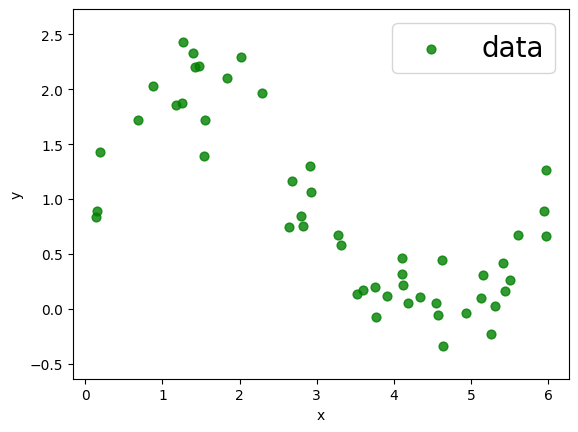

In [2]:
margin = 0.3

# основной график
plt.scatter(data.x_train, data.y_train, 40, 'g', 'o', alpha=0.8, label='data')

# различные "украшения"
plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right', prop={'size': 20})
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [7]:
reg = LinearRegression().fit(data[['x_train']], data.y_train)
y_hat = reg.predict(data[['x_train']])
data[['x_train']]

,x_train
0,0.138368
1,0.157237
2,0.188684
3,0.685553
4,0.874237
5,1.182421
6,1.251605
7,1.270474
8,1.402553
9,1.427711


In [19]:
def generate_degrees(source_data: list, degree: int):
    """Функция, которая принимает на вход одномерный массив, а возвращает n-мерный

    Для каждой степени от 1 до  degree возводим x в эту степень
    """
    return np.array([
          source_data**n for n in range(1, degree + 1)
    ]).T

def train_polynomial(degree, data, prevError):
    """Генерим данные, тренируем модель

    дополнительно рисуем график
    """

    X = generate_degrees(data['x_train'], degree)

    model = LinearRegression().fit(X, data['y_train'])
    y_pred = model.predict(X)

    error = r2_score(data['y_train'], y_pred)
    if round(prevError, 3) >= round(error, 3): return -100
    
    plt.figure()
    plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='degree = ' + str(degree))
    plt.plot(data['x_train'], y_pred)
    plt.show()
    return error

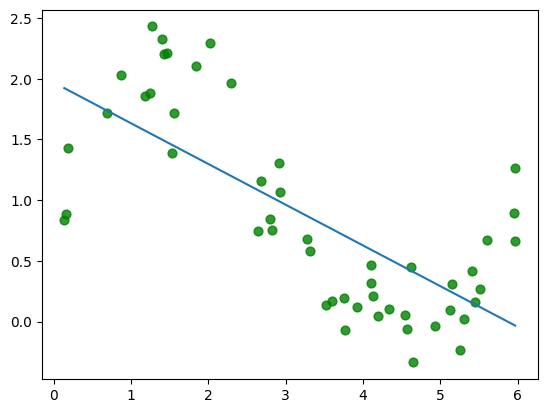

Степень полинома 1 R2 коэффициент детерминации 0.519


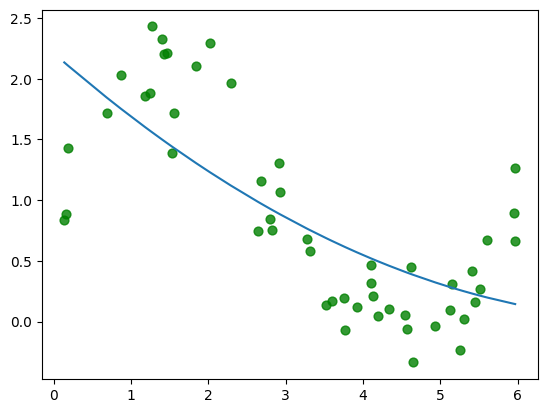

Степень полинома 2 R2 коэффициент детерминации 0.533


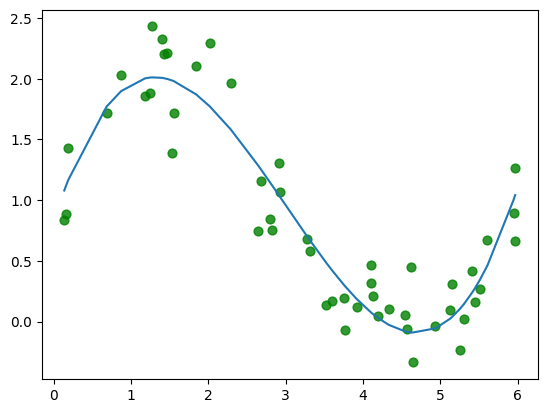

Степень полинома 3 R2 коэффициент детерминации 0.888


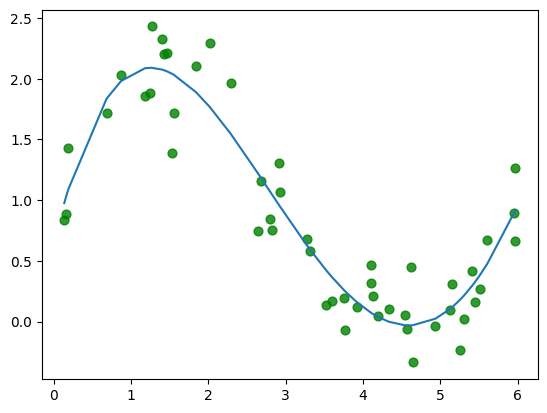

Степень полинома 4 R2 коэффициент детерминации 0.895


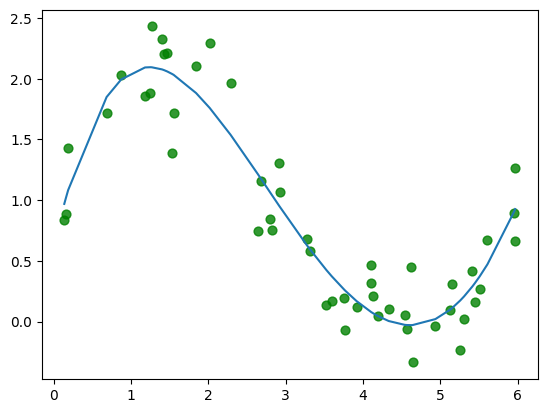

Степень полинома 5 R2 коэффициент детерминации 0.896


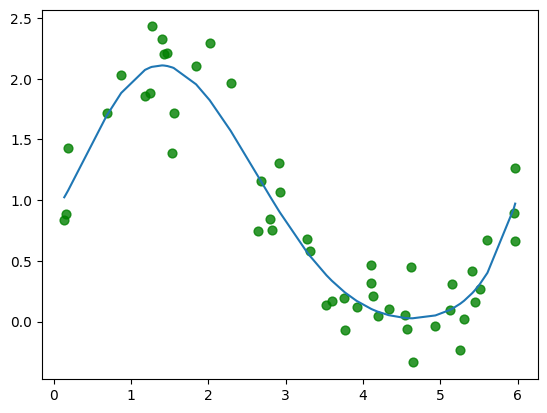

Степень полинома 6 R2 коэффициент детерминации 0.899


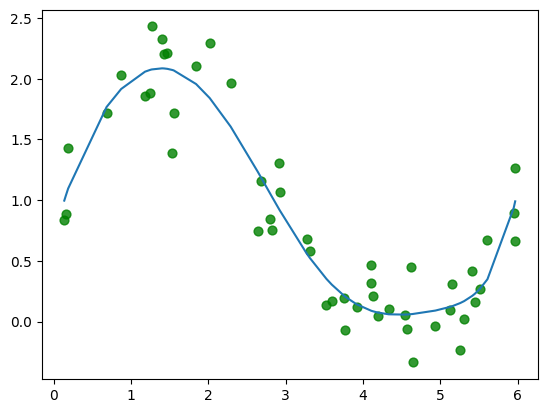

Степень полинома 7 R2 коэффициент детерминации 0.900


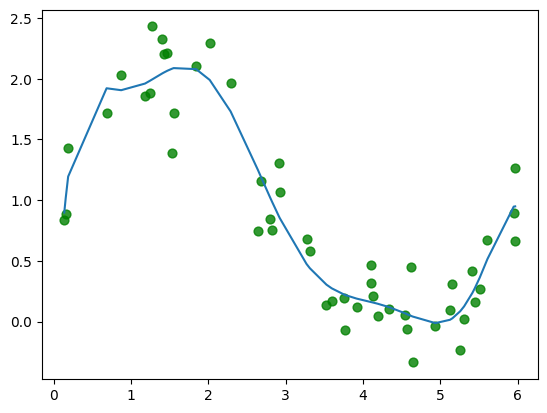

Степень полинома 8 R2 коэффициент детерминации 0.909


In [20]:
prevError = -1
for i in range(1, 11):
    error = train_polynomial(i, data, prevError)
    if error == -100: break
    print("Степень полинома %d R2 коэффициент детерминации %.3f" % (i, error))
    prevError = error

**Задание среднего уровня** Напишите класс для обучения модели, который содержит:

* функцию `.fit(X, y)` , которая принимает на вход массив фичей `X`, массив таргетов `y` и обучает коэффициенты регрессии. Код для обучения взять из первого урока модуля *Постановка ML задачи линейной регрессии*
* функцию `.predict(X)`, которая по массиву фичей `X` возвращает массив предсказаний `y`

Нужно использовать код для аналитически вычисляемых коэффициентов.

Это задание позволит понять, как работает линейная регрессия "внутри" библиотечной реализации.

In [37]:
from numpy.linalg import inv
class CustomLinearReg:
    def __init__(self):
        self.__w = None

    def fit(self, X, Y):
        X_T_X = (X.T).dot(X)
        X_T_X_inverted = inv(X_T_X)
        w = X_T_X_inverted.dot(X.T).dot(Y)
        self.__w = w
        return w

    def predict(self, X):
        print(self.__w)
        Y_pred = self.__w[0][0] + self.__w[1][0]*X
        return Y_pred

In [38]:
X = np.array([[1, 50],[1, 60],[1, 70],[1, 100]])
Y = np.array([[10],[30],[40],[50]])
obj = CustomLinearReg()
w = obj.fit(X, Y)
print("w_1=%.5f, w_2=%.3f" % (w[0][0],w[1][0]))

w_1=-17.50000, w_2=0.714


[[-17.5       ]
 [  0.71428571]]


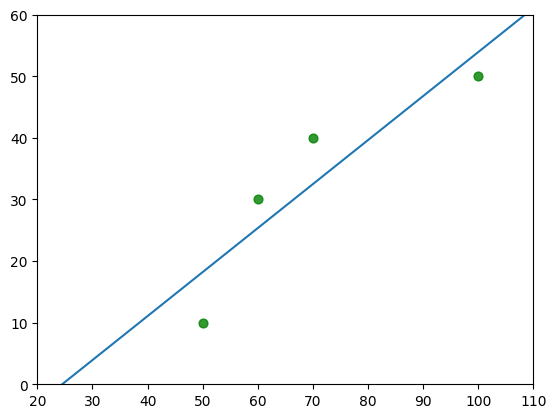

In [39]:
# задаём границы координатных осей
margin = 10
X_min = 20
X_max = X[:,1].max()+margin

# набор точек, чтобы нарисовать прямую
X_support = np.linspace(X_min, X_max, num=100)
Y_model = obj.predict(X_support)
# настройка графика
plt.xlim(X_min, X_max)
plt.ylim(0, Y[:,0].max() + margin)
# рисуем исходные точки
plt.scatter(X[:,1], Y[:,0], 40, 'g', 'o', alpha=0.8)
# предсказания модели
plt.plot(X_support, Y_model)

plt.show()

**Задание высокого уровня**

1. разделите датасет с домами Бостона из Урока 2 (таргет и фичи) на две части: в одной части 80% датасета (назовём train) в другой 20% (назовём valid) с помощью функции `train_test_split` из библиотеки `sklearn`
1. обучите модель только на train датасете
1. постройте предсказания valid датасете
1. Посчитайте  `r2 score` на валидационном сете

После этого примените к обеим датасетам z-преобразование и повторите шаги 2-4. Как изменилась метрика r2?

Это задание поможет понять, как валидировать линейную регрессию (и другие модели) на отложенной выборке.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

boston_dataset = fetch_openml(name='boston', version=1)

features = boston_dataset.data
y = boston_dataset.target
features['CHAS'] = features['CHAS'].astype(float)
features['RAD'] = features['RAD'].astype(float)
features.info()
features.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB


C:\Users\Admin\AppData\Local\Temp\ipykernel_11624\1985242401.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['CHAS'] = features['CHAS'].astype(float)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11624\1985242401.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['RAD'] = features['RAD'].astype(float)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [48]:
X_train, X_test, y_train, y_test = train_test_split(features, y, train_size=0.8, random_state=42)
print(f"Размер тренировочного набора: {X_train.shape}")
print(f"Размер тестового набора: {X_test.shape}")
X_train

Размер тренировочного набора: (404, 13)
Размер тестового набора: (102, 13)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0.0,0.6140,5.304,97.3,2.1007,24.0,666.0,20.2,349.48,24.91
15,0.62739,0.0,8.14,0.0,0.5380,5.834,56.5,4.4986,4.0,307.0,21.0,395.62,8.47
332,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,362.25,7.83
423,7.05042,0.0,18.10,0.0,0.6140,6.103,85.1,2.0218,24.0,666.0,20.2,2.52,23.29
19,0.72580,0.0,8.14,0.0,0.5380,5.727,69.5,3.7965,4.0,307.0,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0.0,0.5200,5.836,91.9,2.2110,5.0,384.0,20.9,395.67,18.66
270,0.29916,20.0,6.96,0.0,0.4640,5.856,42.1,4.4290,3.0,223.0,18.6,388.65,13.00
348,0.01501,80.0,2.01,0.0,0.4350,6.635,29.7,8.3440,4.0,280.0,17.0,390.94,5.99
435,11.16040,0.0,18.10,0.0,0.7400,6.629,94.6,2.1247,24.0,666.0,20.2,109.85,23.27


In [43]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [45]:
from sklearn.metrics import r2_score
y_pred = reg.predict(X_test)
print("r2_score = %s" % r2_score(y_test, y_pred))

r2_score = 0.6687594935356317


In [56]:
scaler = StandardScaler()
X_train_z = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
raw_y = np.array(y_train, dtype=np.float32)
raw_y_test = np.array(y_test, dtype=np.float32)
y_train_z = scaler.fit_transform(raw_y.reshape(-1, 1)).reshape(-1)
X_test_z = pd.DataFrame(scaler.fit_transform(X_test), columns=X_test.columns)
y_test_z = scaler.fit_transform(raw_y_test.reshape(-1, 1)).reshape(-1)
reg = LinearRegression().fit(X_train_z, y_train_z)
y_pred_z = reg.predict(X_test_z)
print("r2_score_z = %s" % r2_score(y_test_z, y_pred_z))

r2_score_z = 0.672726253033332
